# Notebook 8 — PD with Competing Prepayment Risk
## Mortgage Credit Risk Modelling · Freddie Mac Single-Family Loan Dataset

A mortgage can leave the book in two ways: it **defaults**, or it **prepays**. Prepayment covers refinancing, selling the house, or paying off the loan early. In this dataset roughly 10–12 loans prepay for every one that defaults.

A standard survival model treats a prepaid loan as **censored**, meaning "still at risk, we just stopped watching". Converting that model's survival curve into a PD with `1 − S(t)` therefore answers the wrong question. It gives the default probability in a hypothetical world where prepayment has been abolished and every refinanced loan stays exposed forever. That is the *net* (cause-removed) risk.

The PD a provision needs is the *crude* probability: the chance the loan defaults **before anything else happens to it**. That is the **cumulative incidence function (CIF)**, and it is always smaller:

```
CIF_default(t)  ≤  1 − S_default(t)        (an identity, not an empirical finding)
```

Both accumulate the same default-hazard increments. The CIF weights each one by the probability of having survived *both* risks, while the naive figure weights it by survival from default alone, which is always larger.

`src/12_competing_risks.py` estimates the CIF under two deliberately independent specifications:

| | Specification | Data shape | Baseline hazard |
|---|---|---|---|
| **(a)** | Cause-specific Cox: one model per cause, combined into CIFs | One row per loan | Non-parametric (Breslow) |
| **(b)** | Discrete-time multinomial logit over {survive, default, prepay} | Loan-month panel | Binned months-since-origination |

This notebook adds a third, **model-free** reference: the Aalen–Johansen estimator computed directly from the panel.

**Prerequisites:** `src/01_data_preprocessing.py` must have written `surv_{train,oos,oot}.parquet` to the processed-data directory. The cells below run `src/12_competing_risks.py` itself.

In [14]:
import os, shutil, subprocess

REPO = "/kaggle/working/mortgage-credit-risk"
URL  = "https://github.com/MYOUSSF/mortgage-credit-risk"

os.chdir("/kaggle/working")
shutil.rmtree(REPO, ignore_errors=True)
subprocess.run(["git", "clone", "--depth", "1", URL, REPO], check=True, cwd="/kaggle/working")
os.chdir(REPO)

# Point the pipeline at the Kaggle dataset without editing config.py
os.environ["MCR_RAW_DIR"]   = "/kaggle/input/freddie-mac-credit-risk/freddie_mac"
os.environ["MCR_MACRO_DIR"] = "/kaggle/input/freddie-mac-credit-risk/macro"
os.environ["MCR_DATA_DIR"]  = "/kaggle/working/data"     # outputs land here, survive re-clones

print(os.getcwd())

Cloning into '/kaggle/working/mortgage-credit-risk'...


/kaggle/working/mortgage-credit-risk


In [15]:
# src/12_competing_risks.py fits its cause-specific Cox models with lifelines,
# which is not guaranteed to be in the Kaggle image. Install it only if missing.
import sys, subprocess
try:
    import lifelines
    print("lifelines", lifelines.__version__, "already installed")
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lifelines>=0.27.0"], check=True)
    print("lifelines installed")

lifelines 0.30.3 already installed


In [16]:
import os

# Datasets come from the read-only notebook-output mount …
os.environ["MCR_PROC_DIR"] = "/kaggle/input/notebooks/youssefmousaaid/01-eda-ipynb/repo/data/processed"
# … but results must go somewhere writable. Without these, OUT_DIR
# defaults to PROC_DIR and every to_csv() hits:
#   OSError: [Errno 30] Read-only file system
os.environ["MCR_OUT_DIR"] = "/kaggle/working/data/outputs"
os.environ["MCR_FIG_DIR"] = "/kaggle/working/data/figures"

%cd /kaggle/working/mortgage-credit-risk
!python src/12_competing_risks.py

/kaggle/working
20:03:38  INFO      ======================================================================
20:03:38  INFO      Mortgage Credit Risk  |  Ch.10 — Competing Risks (Prepayment)
20:03:38  INFO      ======================================================================
20:03:38  INFO      
20:03:38  INFO      [1/6] Loading the competing-risks panel …
20:03:47  INFO        surv_train.parquet: 39,298,493 rows x 13 columns (2018.8 MB in RAM)
20:03:47  INFO        Train panel: 39,298,493 loan-months, 606,128 loans
20:03:55  INFO          censored  61,519 loans (10.15%)
20:03:55  INFO          default   14,293 loans (2.36%)
20:03:55  INFO          prepay    530,316 loans (87.49%)
20:03:55  INFO          prepay:default = 37.1:1 — the competing risk 1 - S(t) ignores
20:03:55  WARNING     Covariate refi_incentive is entirely missing — dropped.
20:03:55  INFO        Covariates: ['credit_score', 'orig_cltv', 'orig_dti', 'orig_interest_rate', 'log_orig_upb']
20:03:55  INFO        Time g

In [17]:
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from IPython.display import Image, display

plt.rcParams.update({
    "figure.facecolor": "#0F1117", "axes.facecolor": "#0F1117",
    "axes.edgecolor":   "#2D3748", "axes.labelcolor": "#E2E8F0",
    "xtick.color":      "#A0AEC0", "ytick.color":     "#A0AEC0",
    "text.color":       "#E2E8F0", "grid.color":      "#1A2035",
    "legend.facecolor": "#1A2035", "legend.edgecolor":"#2D3748",
    "font.family":      "monospace", "figure.dpi":    120,
})
ACCENT  = "#38BDF8"; DANGER  = "#F87171"
SUCCESS = "#34D399"; WARN    = "#FBBF24"; MUTED = "#94A3B8"
# One colour per curve, used consistently in every chart below.
COL = {"naive": DANGER, "cox": ACCENT, "mnl": WARN, "aj": "#E2E8F0",
       "default": ACCENT, "prepay": SUCCESS, "alive": MUTED}
# ── Paths: resolved from src/config.py, never hardcoded ───────────────────────
# config.py is the single source of truth for directory layout, and it reads
# the MCR_* environment variables set in the setup cell above.
import sys
from pathlib import Path

repo_root = None
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "src" / "config.py").exists():
        repo_root = _candidate
        break
if repo_root is None:
    raise FileNotFoundError(
        "Could not find the repository root containing src/config.py. "
        "Run the setup cell above first."
    )
for _path in [str(repo_root), str(repo_root / "src")]:
    if _path not in sys.path:
        sys.path.insert(0, _path)

import config
import importlib
# config binds the MCR_* variables at import time; reload in case an earlier
# cell imported it before the environment was set.
config = importlib.reload(config)
# savefig() and to_csv() do NOT create parent directories, and on a fresh
# Kaggle session MCR_FIG_DIR/MCR_OUT_DIR point somewhere that does not exist
# yet. Create them once, here, rather than per call site.
config.FIG_DIR.mkdir(parents=True, exist_ok=True)
config.OUT_DIR.mkdir(parents=True, exist_ok=True)

PROC_DIR = config.PROC_DIR   # processed datasets (parquet) — may be read-only
OUT_DIR  = config.OUT_DIR    # derived artifacts (csv) — always writable
FIG_DIR  = config.FIG_DIR
print(f"PROC_DIR = {PROC_DIR}\nOUT_DIR  = {OUT_DIR}\nFIG_DIR  = {FIG_DIR}")

EVENT_TYPE = config.EVENT_TYPE_COL
DURATION   = config.DURATION_COL
E_CENSORED, E_DEFAULT, E_PREPAY = config.EVENT_CENSORED, config.EVENT_DEFAULT, config.EVENT_PREPAY
LABELS     = config.EVENT_TYPE_LABELS
HORIZONS   = config.CR_HORIZONS_MONTHS

needed = [config.CR_COMPARISON_FILE, config.CR_CIF_CURVES_FILE,
          config.CR_COX_COEFS_FILE, config.CR_EXPECTED_LIFE_FILE]
missing = [f for f in needed if not (OUT_DIR / f).exists()]
if missing:
    print("⚠  Missing:", missing, "— check the src/12_competing_risks.py run above.")
else:
    print(f"✓ All {len(needed)} competing-risks outputs present")
if not (OUT_DIR / config.CR_MULTINOMIAL_COEFS_FILE).exists():
    print(f"  ({config.CR_MULTINOMIAL_COEFS_FILE} absent — the statsmodels fit fell back "
          "to sklearn, so clustered standard errors are unavailable this run)")

surv_path = PROC_DIR / config.SURV_TRAIN_FILE
print(f"{'✓' if surv_path.exists() else '⚠ '} {surv_path.name} "
      f"{'found' if surv_path.exists() else 'NOT found — re-run src/01_data_preprocessing.py'}")

comparison = (pd.read_csv(OUT_DIR / config.CR_COMPARISON_FILE)
              if (OUT_DIR / config.CR_COMPARISON_FILE).exists() else None)
curves = (pd.read_csv(OUT_DIR / config.CR_CIF_CURVES_FILE)
          if (OUT_DIR / config.CR_CIF_CURVES_FILE).exists() else None)

PROC_DIR = /kaggle/input/notebooks/youssefmousaaid/01-eda-ipynb/repo/data/processed
OUT_DIR  = /kaggle/working/data/outputs
FIG_DIR  = /kaggle/working/data/figures
✓ All 4 competing-risks outputs present
✓ surv_train.parquet found


## 1. How Loans Leave the Book

Every loan ends in one of three states: **default** (event 1), **prepay** (event 2), or still active at the end of the data (**censored**, event 0). Only the last is genuine censoring.

The panel is read with just the integer columns this notebook needs. Parquet is columnar, so the loan IDs and covariates are never loaded, and the full training panel fits comfortably in memory.

surv_train: 39,298,493 loan-months  (472 MB in RAM)

Loans: 605,779
  default       14,293  (  2.36%)
  prepay       529,976  ( 87.49%)
  censored      61,510  ( 10.15%)

  prepay : default = 37.1 : 1  ← the competing risk that 1 − S(t) ignores


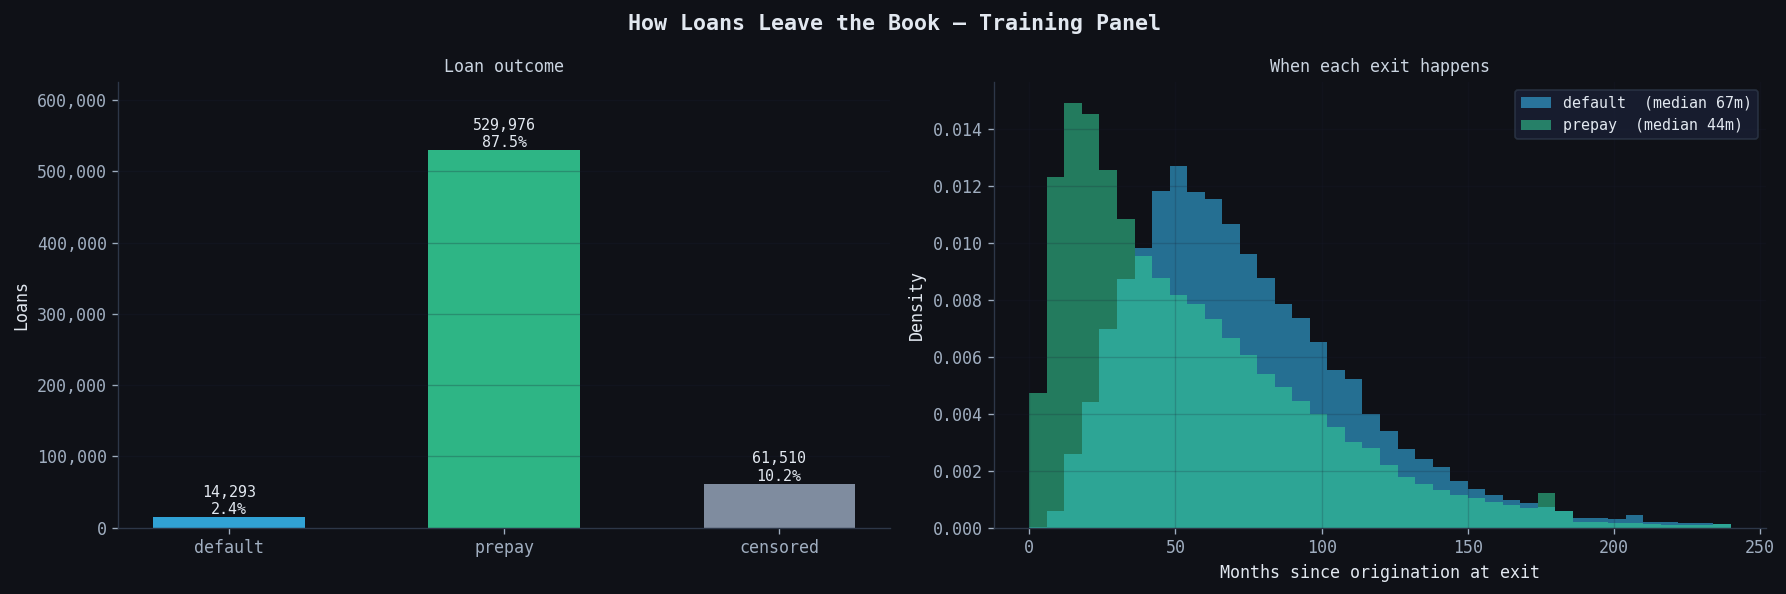

In [18]:
panel = None
if surv_path.exists():
    import pyarrow.parquet as pq
    schema = set(pq.read_schema(surv_path).names)
    want = ["period_month", "period_event", DURATION, EVENT_TYPE, "remaining_months"]
    panel = pd.read_parquet(surv_path, columns=[c for c in want if c in schema])
    for c in panel.columns:
        panel[c] = pd.to_numeric(panel[c], errors="coerce")
    panel = panel.dropna(subset=["period_month", "period_event"])
    for c in ["period_month", "period_event", DURATION, EVENT_TYPE]:
        if c in panel.columns:
            panel[c] = panel[c].astype("int16")
    print(f"surv_train: {len(panel):,} loan-months  "
          f"({panel.memory_usage(deep=True).sum() / 1e6:,.0f} MB in RAM)")

    # One row per loan: its final month, which carries the loan-level outcome.
    last = panel[panel["period_month"] == panel[DURATION]]
    counts = last[EVENT_TYPE].value_counts().reindex([E_DEFAULT, E_PREPAY, E_CENSORED], fill_value=0)
    n_loans = int(counts.sum())

    print(f"\nLoans: {n_loans:,}")
    for code_, n in counts.items():
        print(f"  {LABELS[code_]:9s} {n:>10,}  ({n / max(n_loans, 1):7.2%})")
    if counts[E_DEFAULT]:
        print(f"\n  prepay : default = {counts[E_PREPAY] / counts[E_DEFAULT]:.1f} : 1"
              "  ← the competing risk that 1 − S(t) ignores")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("How Loans Leave the Book — Training Panel",
                 fontsize=13, color="#E2E8F0", fontweight="bold")

    ax = axes[0]
    names  = [LABELS[c] for c in counts.index]
    colors = [COL["default"], COL["prepay"], COL["alive"]]
    bars = ax.bar(names, counts.values, color=colors, alpha=0.85, width=0.55)
    for bar, n in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, n, f"{n:,}\n{n / max(n_loans, 1):.1%}",
                ha="center", va="bottom", fontsize=9, color="#E2E8F0")
    ax.set_ylim(0, counts.max() * 1.18)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_ylabel("Loans", fontsize=10)
    ax.set_title("Loan outcome", color="#CBD5E1", fontsize=10)
    ax.grid(True, axis="y", alpha=0.25)

    ax = axes[1]
    max_m = int(last[DURATION].quantile(0.995))
    bins = np.arange(0, max_m + 6, 6)
    for code_ in (E_DEFAULT, E_PREPAY):
        d = last.loc[last[EVENT_TYPE] == code_, DURATION]
        if len(d):
            ax.hist(d, bins=bins, density=True, alpha=0.55, color=colors[[E_DEFAULT, E_PREPAY].index(code_)],
                    label=f"{LABELS[code_]}  (median {d.median():.0f}m)")
    ax.set_xlabel("Months since origination at exit", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_title("When each exit happens", color="#CBD5E1", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    for a in axes:
        a.spines["top"].set_visible(False); a.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()
else:
    print("surv_train.parquet not found. Run src/01_data_preprocessing.py first.")

## 2. Model-Free Benchmark — Aalen–Johansen vs Kaplan–Meier

Before looking at either model, the same comparison can be made **non-parametrically** on the panel. At each month since origination `k`, the panel gives the loans at risk `n_k`, the defaults `d_k` and the prepayments `p_k`:

```
Kaplan–Meier "PD" (naive):  1 − ∏ (1 − d_j/n_j)                          prepayment treated as censoring
Aalen–Johansen CIF:         Σ  d_k/n_k · S(k−1),   S(k) = ∏ (1 − (d_j + p_j)/n_j)
```

Risk sets are built from the panel rows themselves, so loans entering the data after origination (delayed entry) are handled correctly. The tail is cut where fewer than `MIN_AT_RISK` loans remain, because there a single event moves the curve.

The model curves are portfolio averages over the training loans, with covariates at origination. They estimate the same marginal quantity, so where they track the empirical curve, the model has the level right.

Aalen–Johansen on 263 months (risk set ≥ threshold throughout)
 month     at risk   naive KM     AJ CIF  overstated  AJ prepay
   12m     543,774    0.0126%    0.0117%       +7.2%     10.46%
   24m     451,861    0.1511%    0.1235%      +22.3%     25.93%
   36m     377,358    0.4883%    0.3518%      +38.8%     37.94%
   60m     266,631    1.7603%    1.0162%      +73.2%     55.76%
  120m      91,139    5.4205%    2.0947%     +158.8%     80.91%


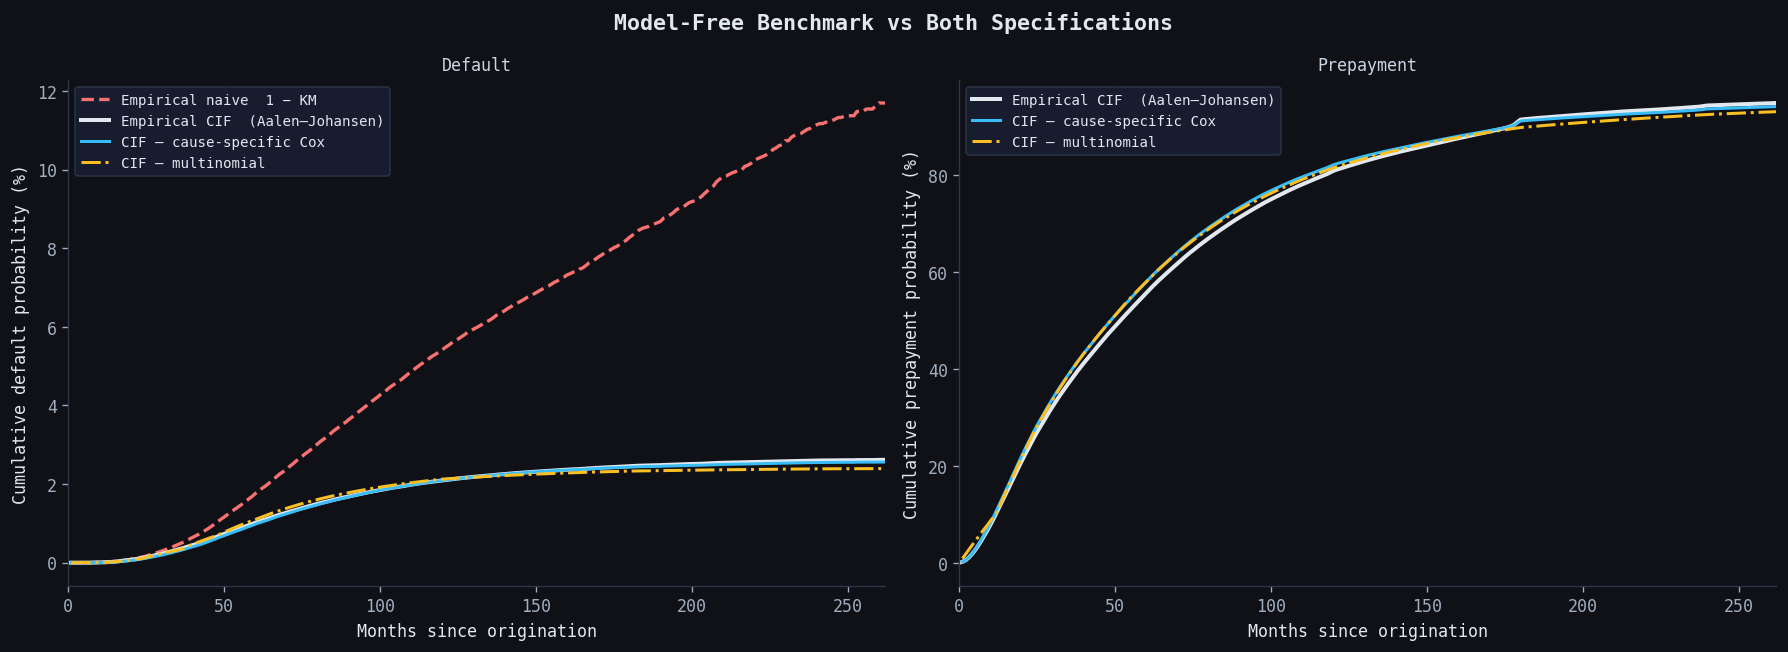

In [19]:
MIN_AT_RISK = 1_000

aj = None
if panel is not None and len(panel):
    g = panel.groupby("period_month")["period_event"]
    aj = pd.DataFrame({
        "n_at_risk": g.size(),
        "d_default": g.apply(lambda s: int((s == E_DEFAULT).sum())),
        "d_prepay":  g.apply(lambda s: int((s == E_PREPAY).sum())),
    }).sort_index()
    # Keep the months before the risk set first thins below the threshold.
    thin = aj.index[aj["n_at_risk"] < min(MIN_AT_RISK, aj["n_at_risk"].max() * 0.01)]
    if len(thin):
        aj = aj.loc[: thin.min() - 1]
    h_d = aj["d_default"] / aj["n_at_risk"]
    h_p = aj["d_prepay"]  / aj["n_at_risk"]
    aj["survival"]   = (1 - h_d - h_p).cumprod()
    s_prev           = aj["survival"].shift(1, fill_value=1.0)
    aj["cif_default"] = (h_d * s_prev).cumsum()
    aj["cif_prepay"]  = (h_p * s_prev).cumsum()
    aj["naive_km"]    = 1 - (1 - h_d).cumprod()

    print(f"Aalen–Johansen on {len(aj)} months (risk set ≥ threshold throughout)")
    print("=" * 78)
    print(f"{'month':>6s} {'at risk':>11s} {'naive KM':>10s} {'AJ CIF':>10s} {'overstated':>11s}"
          f" {'AJ prepay':>10s}")
    for m in [h for h in HORIZONS + [60, 120] if h in aj.index]:
        r = aj.loc[m]
        over = (r["naive_km"] / r["cif_default"] - 1) if r["cif_default"] > 0 else np.nan
        print(f"{m:>5d}m {int(r['n_at_risk']):>11,} {r['naive_km']:>10.4%} {r['cif_default']:>10.4%}"
              f" {over:>+11.1%} {r['cif_prepay']:>10.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    fig.suptitle("Model-Free Benchmark vs Both Specifications",
                 fontsize=13, color="#E2E8F0", fontweight="bold")

    ax = axes[0]
    ax.plot(aj.index, aj["naive_km"] * 100, color=COL["naive"], linewidth=2, linestyle="--",
            label="Empirical naive  1 − KM")
    ax.plot(aj.index, aj["cif_default"] * 100, color=COL["aj"], linewidth=2.4,
            label="Empirical CIF  (Aalen–Johansen)")
    if curves is not None:
        ax.plot(curves["month"], curves["cif_default_cox"] * 100, color=COL["cox"],
                linewidth=1.8, label="CIF — cause-specific Cox")
        ax.plot(curves["month"], curves["cif_default_multinomial"] * 100, color=COL["mnl"],
                linewidth=1.8, linestyle="-.", label="CIF — multinomial")
    ax.set_xlim(0, aj.index.max())
    ax.set_ylabel("Cumulative default probability (%)", fontsize=10)
    ax.set_title("Default", color="#CBD5E1", fontsize=10)

    ax = axes[1]
    ax.plot(aj.index, aj["cif_prepay"] * 100, color=COL["aj"], linewidth=2.4,
            label="Empirical CIF  (Aalen–Johansen)")
    if curves is not None:
        ax.plot(curves["month"], curves["cif_prepay_cox"] * 100, color=COL["cox"],
                linewidth=1.8, label="CIF — cause-specific Cox")
        ax.plot(curves["month"], curves["cif_prepay_multinomial"] * 100, color=COL["mnl"],
                linewidth=1.8, linestyle="-.", label="CIF — multinomial")
    ax.set_xlim(0, aj.index.max())
    ax.set_ylabel("Cumulative prepayment probability (%)", fontsize=10)
    ax.set_title("Prepayment", color="#CBD5E1", fontsize=10)

    for a in axes:
        a.set_xlabel("Months since origination", fontsize=10)
        a.legend(fontsize=8.5, loc="upper left")
        a.grid(True, alpha=0.2)
        a.spines["top"].set_visible(False); a.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "competing_risks_aalen_johansen.png",
                dpi=150, bbox_inches="tight", facecolor="#0F1117")
    plt.show()
else:
    print("Panel not loaded — see §1.")

## 3. The Headline — How Much Does `1 − S(t)` Overstate PD?

`overstatement_pct` is measured against the Cox CIF, specification (a), and expressed as a percentage *of* the CIF:

```
overstatement = (naive − CIF) / CIF
```

So "+45%" reads as "the naive PD is 45% larger than the correct one". That is the error a provision built on the naive PD would carry.

The gap grows with horizon. Over 12 months few loans have prepaid yet, so the two figures are close. Over a lifetime most of the cohort has refinanced, and the naive PD keeps charging default risk to loans that no longer exist.

Naive 1 − S(t) vs Cumulative Incidence of Default
 horizon  horizon_months naive_1_minus_S cif_cox cif_multinomial overstatement_pct spec_gap_pct
     12m              12         0.0073% 0.0067%         0.0069%             +9.1%        +3.0%
     24m              24         0.1280% 0.1005%         0.1123%            +27.3%       +11.8%
     36m              36         0.4567% 0.3115%         0.3372%            +46.6%        +8.2%
lifetime             307        12.9266% 2.5921%         2.4042%           +398.7%        -7.2%


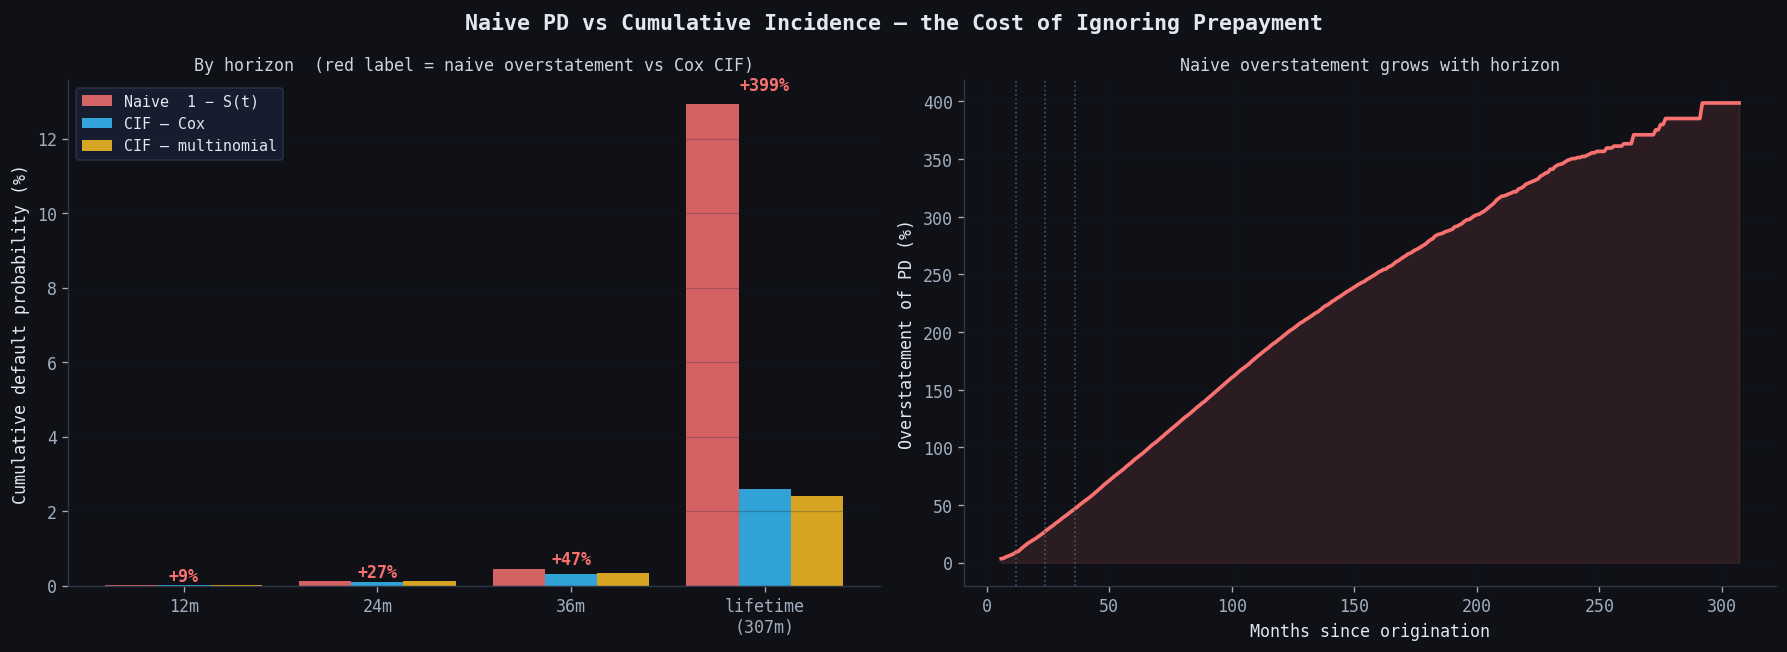


Identity check  max(CIF − naive) = 0.00e+00  → OK (≤ 0)


In [20]:
if comparison is not None:
    show = comparison.copy()
    for c in ["naive_1_minus_S", "cif_cox", "cif_multinomial"]:
        show[c] = show[c].map(lambda v: f"{v:.4%}")
    for c in ["overstatement_pct", "spec_gap_pct"]:
        show[c] = show[c].map(lambda v: f"{v:+.1f}%")
    print("Naive 1 − S(t) vs Cumulative Incidence of Default")
    print("=" * 96)
    print(show.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    fig.suptitle("Naive PD vs Cumulative Incidence — the Cost of Ignoring Prepayment",
                 fontsize=13, color="#E2E8F0", fontweight="bold")

    ax = axes[0]
    x = np.arange(len(comparison))
    w = 0.27
    for k, (col, lab, c) in enumerate([("naive_1_minus_S", "Naive  1 − S(t)", COL["naive"]),
                                       ("cif_cox", "CIF — Cox", COL["cox"]),
                                       ("cif_multinomial", "CIF — multinomial", COL["mnl"])]):
        ax.bar(x + (k - 1) * w, comparison[col] * 100, w, color=c, alpha=0.85, label=lab)
    for i, r in comparison.iterrows():
        top = max(r["naive_1_minus_S"], r["cif_cox"], r["cif_multinomial"]) * 100
        ax.text(i, top * 1.02, f"{r['overstatement_pct']:+.0f}%", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=COL["naive"])
    labels = [f"{h}\n({m}m)" if h == "lifetime" else h
              for h, m in zip(comparison["horizon"], comparison["horizon_months"])]
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Cumulative default probability (%)", fontsize=10)
    ax.set_title("By horizon  (red label = naive overstatement vs Cox CIF)",
                 color="#CBD5E1", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", alpha=0.25)

    ax = axes[1]
    if curves is not None:
        valid = curves["cif_default_cox"] > 1e-6
        over = ((curves["naive_1_minus_S"] - curves["cif_default_cox"])
                / curves["cif_default_cox"]).where(valid) * 100
        ax.plot(curves["month"], over, color=COL["naive"], linewidth=2.2)
        ax.fill_between(curves["month"], 0, over, color=COL["naive"], alpha=0.12)
        for h in HORIZONS:
            ax.axvline(h, color="#4B5563", linewidth=1, linestyle=":")
        ax.set_xlabel("Months since origination", fontsize=10)
        ax.set_ylabel("Overstatement of PD (%)", fontsize=10)
        ax.set_title("Naive overstatement grows with horizon", color="#CBD5E1", fontsize=10)
        ax.grid(True, alpha=0.2)
    for a in axes:
        a.spines["top"].set_visible(False); a.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()

    # The identity CIF ≤ 1 − S holds interval by interval; a violation is a bug.
    if curves is not None:
        worst = float((curves["cif_default_cox"] - curves["naive_1_minus_S"]).max())
        print(f"\nIdentity check  max(CIF − naive) = {worst:.2e}  "
              f"→ {'OK (≤ 0)' if worst <= 1e-9 else 'VIOLATED — investigate the combination step'}")
else:
    print(f"{config.CR_COMPARISON_FILE} not found. Run src/12_competing_risks.py first.")

## 4. Where the Cohort Goes

At every month, each original loan is in exactly one of three states: defaulted, prepaid, or still alive. The CIFs and overall survival therefore partition the cohort:

```
CIF_default(t) + CIF_prepay(t) + S(t) = 1
```

Both specifications are built so that this holds exactly. The Cox combination uses the exact interval exit probability, and the multinomial's shared softmax keeps `h_d + h_p < 1`. The stacked chart makes the scale of the problem visible: default is the thin band at the bottom, and prepayment is what actually empties the book.

Cause-specific Cox           partition check  max|CIF_d + CIF_p + S − 1| = 5.08e-14
Discrete-time multinomial    partition check  max|CIF_d + CIF_p + S − 1| = 5.38e-14


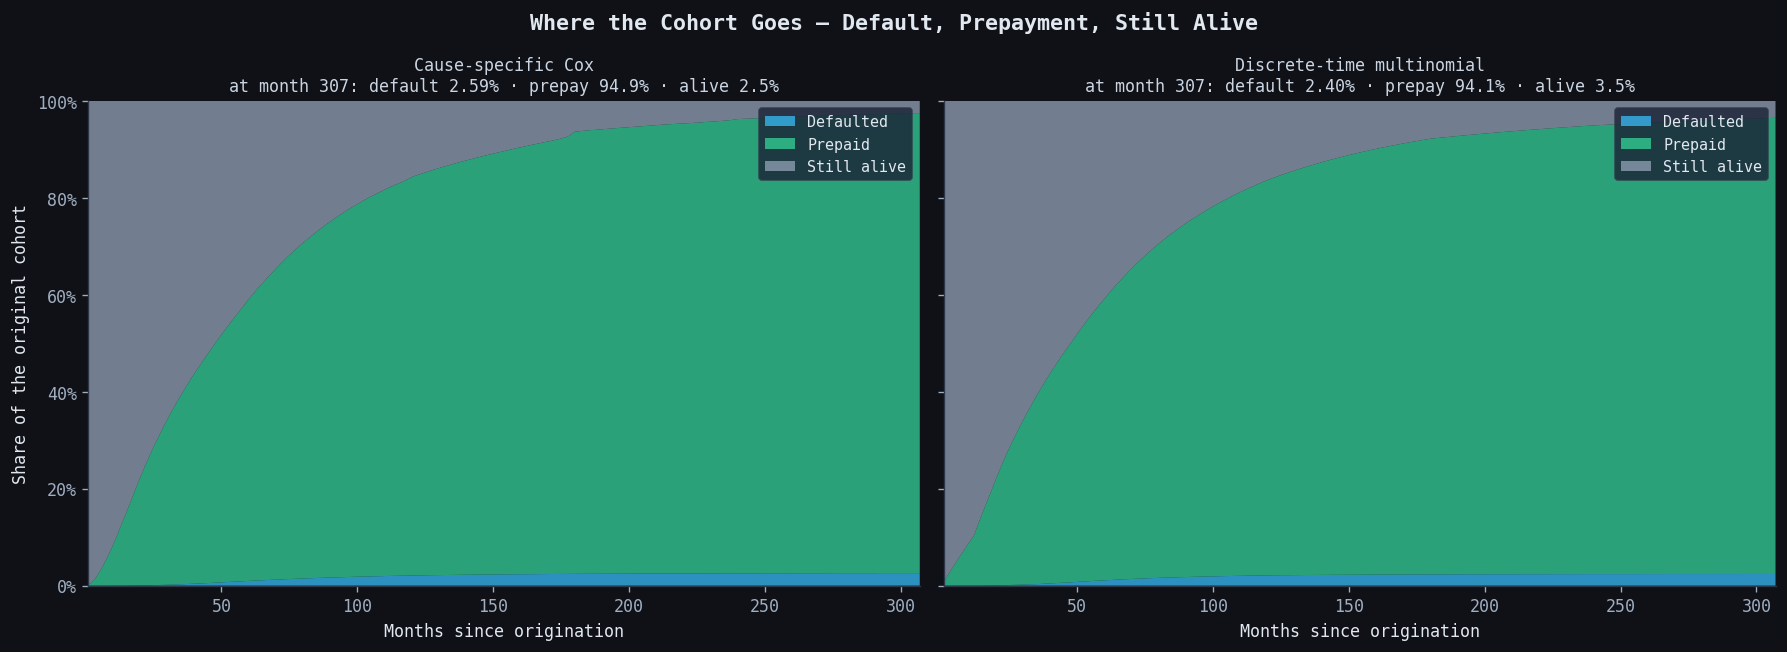

In [21]:
if curves is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
    fig.suptitle("Where the Cohort Goes — Default, Prepayment, Still Alive",
                 fontsize=13, color="#E2E8F0", fontweight="bold")
    for ax, (spec, suffix) in zip(axes, [("Cause-specific Cox", "cox"),
                                         ("Discrete-time multinomial", "multinomial")]):
        d = curves[f"cif_default_{suffix}"] * 100
        p = curves[f"cif_prepay_{suffix}"] * 100
        s = curves[f"survival_{suffix}"] * 100
        ax.stackplot(curves["month"], d, p, s,
                     colors=[COL["default"], COL["prepay"], COL["alive"]], alpha=0.75,
                     labels=["Defaulted", "Prepaid", "Still alive"])
        partition = float(((d + p + s) / 100 - 1).abs().max())
        end = curves.iloc[-1]
        ax.set_title(f"{spec}\nat month {int(end['month'])}: "
                     f"default {end[f'cif_default_{suffix}']:.2%} · "
                     f"prepay {end[f'cif_prepay_{suffix}']:.1%} · "
                     f"alive {end[f'survival_{suffix}']:.1%}",
                     color="#CBD5E1", fontsize=10)
        ax.set_xlabel("Months since origination", fontsize=10)
        ax.set_xlim(curves["month"].min(), curves["month"].max()); ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.legend(fontsize=9, loc="upper right")
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        print(f"{spec:28s} partition check  max|CIF_d + CIF_p + S − 1| = {partition:.2e}")
    axes[0].set_ylabel("Share of the original cohort", fontsize=10)
    plt.tight_layout(); plt.show()

## 5. Specification (a) — Cause-Specific Cox Hazard Ratios

Two Cox models are fitted on one row per loan, with covariates at **origination** (the first row, so there is no end-of-follow-up leakage):

- **Default model:** default is the event, and prepayment is censored at its exit time.
- **Prepayment model:** prepayment is the event, and default is censored.

Censoring the competing event *here* is correct. A cause-specific hazard is estimated exactly this way. The error the script corrects happens in the *conversion* to a probability, not in the fit.

Reading the two sets of hazard ratios side by side shows why the risks interact. A covariate that raises the prepayment hazard, such as a large refinancing incentive, *lowers* the default CIF even when it has no effect on the default hazard itself, because it removes loans from the at-risk pool before they can default. Hazard ratios are rescaled to readable economic steps, and confidence bounds transform exactly.

Cause-Specific Cox — Hazard Ratios per Economic Step
                                          hr                 p           
cause                                default prepay    default     prepay
label                                                                    
credit_score  (+20 FICO pts)          0.9479   1.04  4.54e-303          0
log_orig_upb  (×2 orig. balance)       1.014  1.268   0.001971          0
orig_cltv  (+10pp CLTV)                1.064 0.9806 2.098e-171 9.268e-133
orig_dti  (+5pp DTI)                   1.038 0.9811 1.065e-106  1.08e-211
orig_interest_rate  (+1pp note rate)   1.145  1.318          0          0


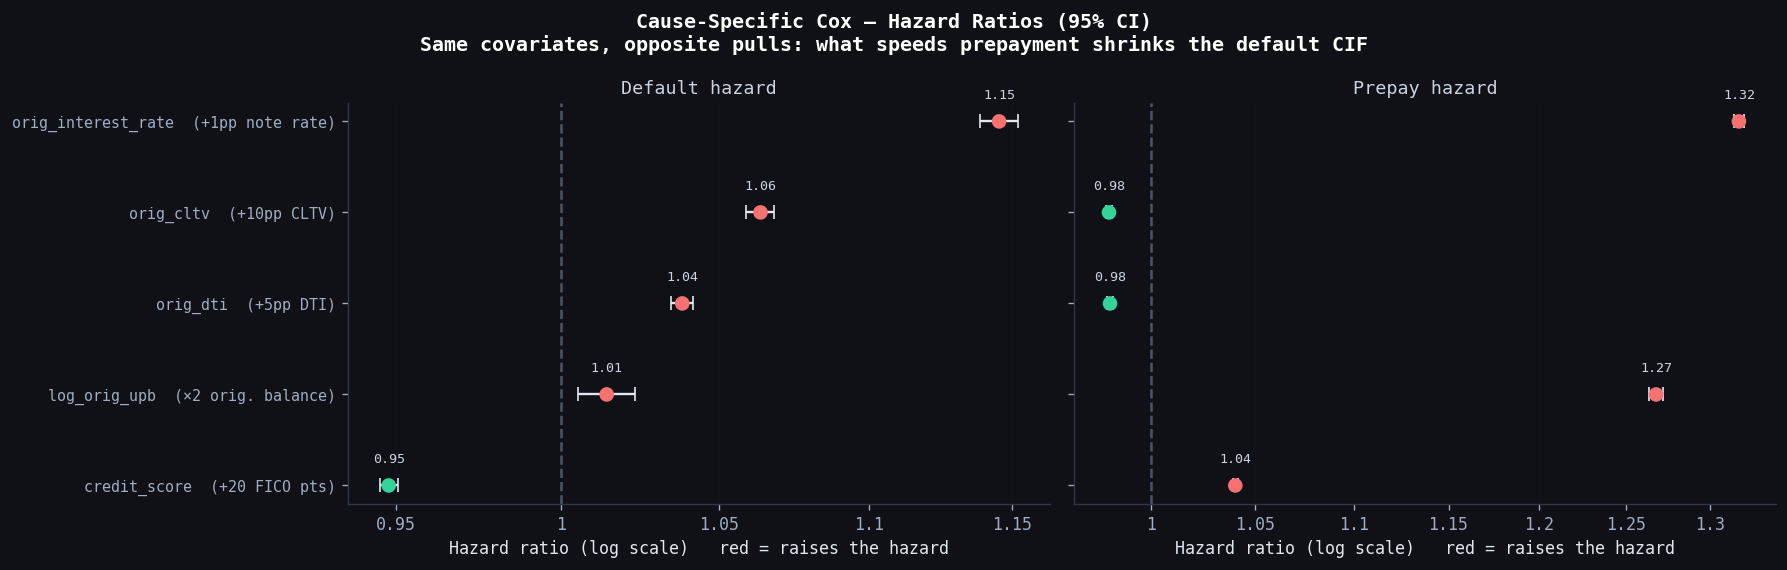

In [22]:
cox_path = OUT_DIR / config.CR_COX_COEFS_FILE

# Economically meaningful step per covariate. refi_incentive is the note rate
# minus the current PMMS rate, in percentage points; log_orig_upb × ln 2 is a
# doubling of the original balance.
STEP = {
    "credit_score":       (20,        "+20 FICO pts"),
    "orig_cltv":          (10,        "+10pp CLTV"),
    "orig_dti":           (5,         "+5pp DTI"),
    "orig_interest_rate": (1,         "+1pp note rate"),
    "log_orig_upb":       (np.log(2), "×2 orig. balance"),
    "refi_incentive":     (1,         "+1pp refi incentive"),
}

if cox_path.exists():
    cox = pd.read_csv(cox_path)
    lo_col = "coef lower 95%" if "coef lower 95%" in cox.columns else None
    hi_col = "coef upper 95%" if "coef upper 95%" in cox.columns else None
    cox["step"]  = cox["covariate"].map(lambda c: STEP.get(c, (1, c))[0])
    cox["label"] = cox["covariate"].map(lambda c: f"{c}  ({STEP[c][1]})" if c in STEP else c)
    cox["hr"]    = np.exp(cox["coef"] * cox["step"])
    cox["hr_lo"] = np.exp(cox[lo_col] * cox["step"]) if lo_col else np.nan
    cox["hr_hi"] = np.exp(cox[hi_col] * cox["step"]) if hi_col else np.nan

    table = cox.pivot(index="label", columns="cause", values=["hr", "p"] if "p" in cox else ["hr"])
    print("Cause-Specific Cox — Hazard Ratios per Economic Step")
    print("=" * 80)
    print(table.to_string(float_format=lambda v: f"{v:.4g}"))

    order = (cox[cox["cause"] == "default"].sort_values("hr")["label"].tolist()
             or sorted(cox["label"].unique()))
    fig, axes = plt.subplots(1, 2, figsize=(15, max(4.5, len(order) * 0.6 + 1.8)), sharey=True)
    fig.suptitle("Cause-Specific Cox — Hazard Ratios (95% CI)\n"
                 "Same covariates, opposite pulls: what speeds prepayment shrinks the default CIF",
                 fontsize=12, fontweight="bold", color="white")
    for ax, cause in zip(axes, ["default", "prepay"]):
        sub = cox[cox["cause"] == cause].set_index("label").reindex(order)
        y = np.arange(len(sub))
        hr, lo, hi = sub["hr"].to_numpy(), sub["hr_lo"].to_numpy(), sub["hr_hi"].to_numpy()
        colors = [DANGER if v > 1 else SUCCESS for v in hr]
        if np.isfinite(lo).all():
            ax.errorbar(hr, y, xerr=[np.maximum(hr - lo, 0), np.maximum(hi - hr, 0)],
                        fmt="none", ecolor="#E2E8F0", elinewidth=1.4, capsize=4)
        ax.scatter(hr, y, color=colors, s=60, zorder=5)
        for yy, v in zip(y, hr):
            ax.text(v, yy + 0.25, f"{v:.2f}", ha="center", fontsize=8, color="#CBD5E1")
        ax.axvline(1.0, color="#4B5563", linewidth=1.5, linestyle="--")
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}"))
        ax.xaxis.set_minor_formatter(mtick.NullFormatter())
        ax.xaxis.set_major_locator(mtick.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
        ax.set_yticks(y); ax.set_yticklabels(order, fontsize=9)
        ax.set_xlabel("Hazard ratio (log scale)   red = raises the hazard", fontsize=10)
        ax.set_title(f"{cause.title()} hazard", color="#CBD5E1", fontsize=11)
        ax.grid(True, axis="x", alpha=0.2)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()
else:
    print(f"{config.CR_COX_COEFS_FILE} not found. Run src/12_competing_risks.py first.")

## 6. Specification (b) — Discrete-Time Multinomial Hazard

One row per loan-month at risk, with a three-class multinomial logit over {survive, default, prepay}:

```
h_d(k) = P(default in month k | alive),   h_p(k) = P(prepay in month k | alive)
S(k)   = ∏ (1 − h_d − h_p),               CIF_d(t) = Σ h_d(k) · S(k−1)
```

- **Shared softmax.** The denominator is common to all three classes, so `h_d + h_p < 1` by construction. Two independent binary logits give no such guarantee. If each predicts 0.7, the implied monthly survival goes negative and silently corrupts every later term.
- **Clustered standard errors.** SEs are clustered by loan, because consecutive months of one loan are not independent observations.
- **Duration bins as the baseline.** A logit has no baseline hazard of its own, so months-since-origination enters as a binned factor (`config.CR_DURATION_BIN_EDGES`). Bins too sparse to identify are merged automatically.

The coefficients are log-odds *against surviving the month*. At mortgage-sized monthly hazards those are close to log hazard ratios, so they can be compared directly with the Cox estimates in §5.

Multinomial — covariate effects (odds vs surviving the month, per economic step)
                   or_step              z       
outcome_vs_survive default prepay default prepay
covariate                                       
credit_score        0.8985  1.052  -19.95  45.24
log_orig_upb         1.482  1.346   17.15  85.29
orig_cltv            1.358 0.9741   25.91 -17.25
orig_dti             1.118 0.9754   15.58 -21.12
orig_interest_rate   2.284   1.41   49.51  132.6

Cox vs multinomial, per economic step
                    default_cox_HR  prepay_cox_HR  default_mnl_OR  prepay_mnl_OR
covariate                                                                       
credit_score                0.9479           1.04          0.8985          1.052
log_orig_upb                 1.014          1.268           1.482          1.346
orig_cltv                    1.064         0.9806           1.358         0.9741
orig_dti                     1.038         0.9811           1.118         0.9754
or

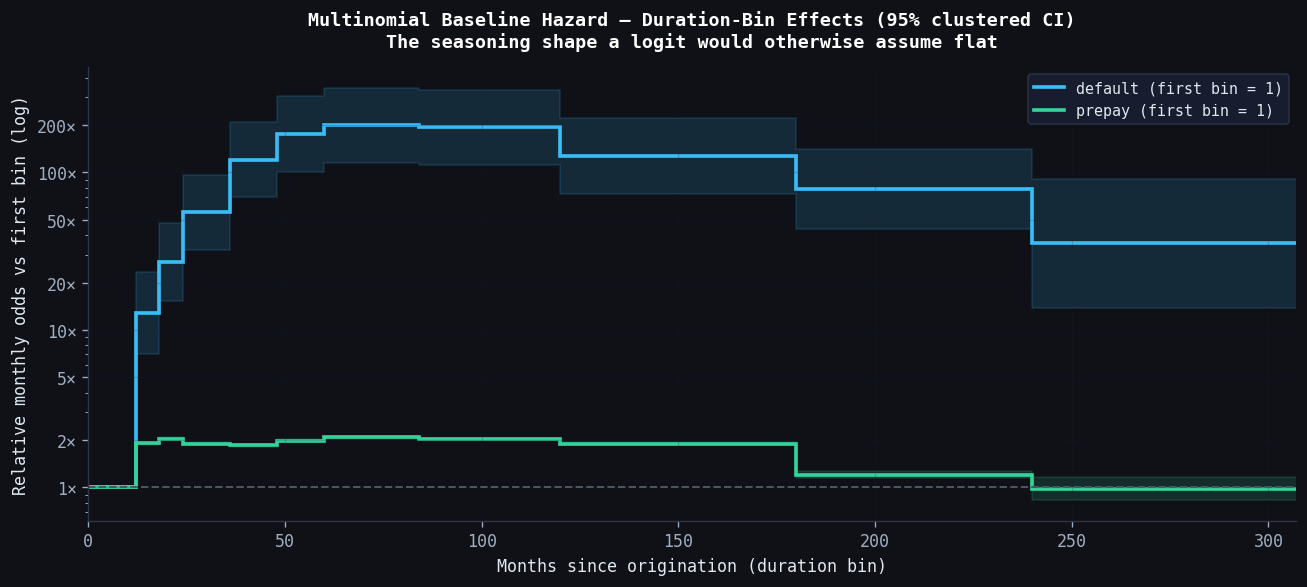


──────────────────────────────────────────────────────────────────────
  Mean monthly cause-specific hazards (multinomial, from the script)
──────────────────────────────────────────────────────────────────────


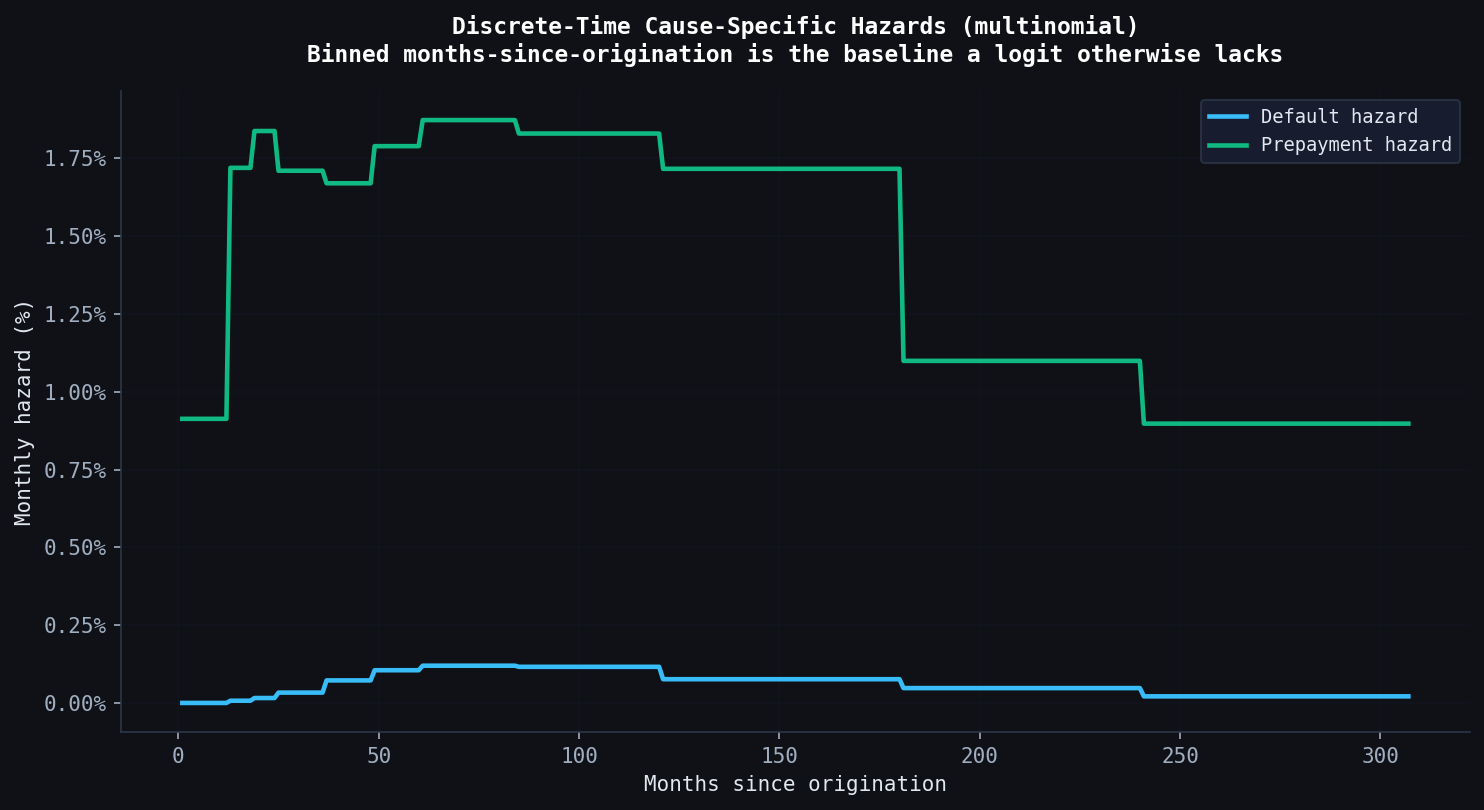

In [23]:
import re

mnl_path = OUT_DIR / config.CR_MULTINOMIAL_COEFS_FILE
if mnl_path.exists():
    mnl = pd.read_csv(mnl_path)
    mnl["z"] = mnl["coef"] / mnl["std_err_clustered"]
    cov_rows = mnl[~mnl["covariate"].str.startswith("dur_") & (mnl["covariate"] != "const")].copy()
    cov_rows["step"] = cov_rows["covariate"].map(lambda c: STEP.get(c, (1, c))[0])
    cov_rows["or_step"] = np.exp(cov_rows["coef"] * cov_rows["step"])

    print("Multinomial — covariate effects (odds vs surviving the month, per economic step)")
    print("=" * 92)
    wide = cov_rows.pivot(index="covariate", columns="outcome_vs_survive",
                          values=["or_step", "z"])
    print(wide.to_string(float_format=lambda v: f"{v:.4g}"))

    # Side-by-side with Cox: do the two specifications agree on direction?
    if cox_path.exists():
        cox_hr = cox.pivot(index="covariate", columns="cause", values="hr")
        mnl_or = cov_rows.pivot(index="covariate", columns="outcome_vs_survive", values="or_step")
        both = cox_hr.join(mnl_or, lsuffix="_cox_HR", rsuffix="_mnl_OR", how="inner")
        agree = []
        for cause in ["default", "prepay"]:
            a, b = f"{cause}_cox_HR", f"{cause}_mnl_OR"
            if a in both and b in both:
                agree.append((np.sign(np.log(both[a])) == np.sign(np.log(both[b]))).mean())
        print("\nCox vs multinomial, per economic step")
        print(both.to_string(float_format=lambda v: f"{v:.4g}"))
        if agree:
            print(f"Direction agreement across covariates and causes: {np.mean(agree):.0%}")

    # Baseline: the duration-bin dummies, as a relative hazard vs the first bin.
    dur = mnl[mnl["covariate"].str.startswith("dur_")].copy()
    if not dur.empty:
        dur["upper"] = dur["covariate"].map(
            lambda s: float(re.findall(r"[-\d.]+", s)[-1]))
        dur["lower"] = dur["covariate"].map(
            lambda s: float(re.findall(r"[-\d.]+", s)[-2]))
        fig, ax = plt.subplots(figsize=(11, 5))
        x_max = 0.0
        for outcome, c in [(LABELS[E_DEFAULT], COL["default"]), (LABELS[E_PREPAY], COL["prepay"])]:
            sub = dur[dur["outcome_vs_survive"] == outcome].sort_values("upper")
            if sub.empty:
                continue
            # Reference bin runs from 0 to the first dummy's lower edge; the
            # dummies' bins are contiguous after that.
            edges = np.r_[0.0, sub["lower"].to_numpy(), sub["upper"].to_numpy()[-1]]
            rel = np.r_[1.0, np.exp(sub["coef"].to_numpy())]
            lo_ = np.r_[1.0, np.exp(sub["coef"] - 1.96 * sub["std_err_clustered"]).to_numpy()]
            hi_ = np.r_[1.0, np.exp(sub["coef"] + 1.96 * sub["std_err_clustered"]).to_numpy()]
            ax.stairs(rel, edges, baseline=None, color=c, linewidth=2.2,
                      label=f"{outcome} (first bin = 1)")
            x_max = max(x_max, sub["lower"].max())
            ax.fill_between(edges, np.r_[lo_, lo_[-1]], np.r_[hi_, hi_[-1]],
                            step="post", color=c, alpha=0.15)
        ax.axhline(1.0, color="#4B5563", linewidth=1.2, linestyle="--")
        # The last bin's upper edge is a catch-all (up to 480m); stop the axis
        # at the observed follow-up instead of drawing decades of flat line.
        obs_max = curves["month"].max() if curves is not None else x_max * 1.5
        ax.set_xlim(0, max(obs_max, x_max * 1.1))
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}×"))
        ax.yaxis.set_minor_formatter(mtick.NullFormatter())
        ax.yaxis.set_major_locator(mtick.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
        ax.set_xlabel("Months since origination (duration bin)", fontsize=10)
        ax.set_ylabel("Relative monthly odds vs first bin (log)", fontsize=10)
        ax.set_title("Multinomial Baseline Hazard — Duration-Bin Effects (95% clustered CI)\n"
                     "The seasoning shape a logit would otherwise assume flat",
                     fontsize=11, fontweight="bold", color="white", pad=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.2)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        plt.tight_layout(); plt.show()
else:
    print(f"{config.CR_MULTINOMIAL_COEFS_FILE} not found — either the script has not been run, "
          "or the statsmodels fit fell back to sklearn (no clustered SEs); see its log.")

path = FIG_DIR / "competing_risks_hazards.png"
if path.exists():
    print(f"\n{'─'*70}\n  Mean monthly cause-specific hazards (multinomial, from the script)\n{'─'*70}")
    display(Image(str(path), width=820))

## 7. Do the Two Specifications Agree?

The specifications are fitted to different data shapes (loan-level vs loan-month), with different likelihoods and different baseline treatments. **Agreement between them is therefore evidence**, and the comparison reports the gap rather than averaging it away.

The script uses a ±5% tolerance at 36 months. A wider gap usually means one of three things:
- the duration bins are too coarse where the hazard moves fastest;
- the functional forms differ materially;
- there are too few default events to identify both models comparably.

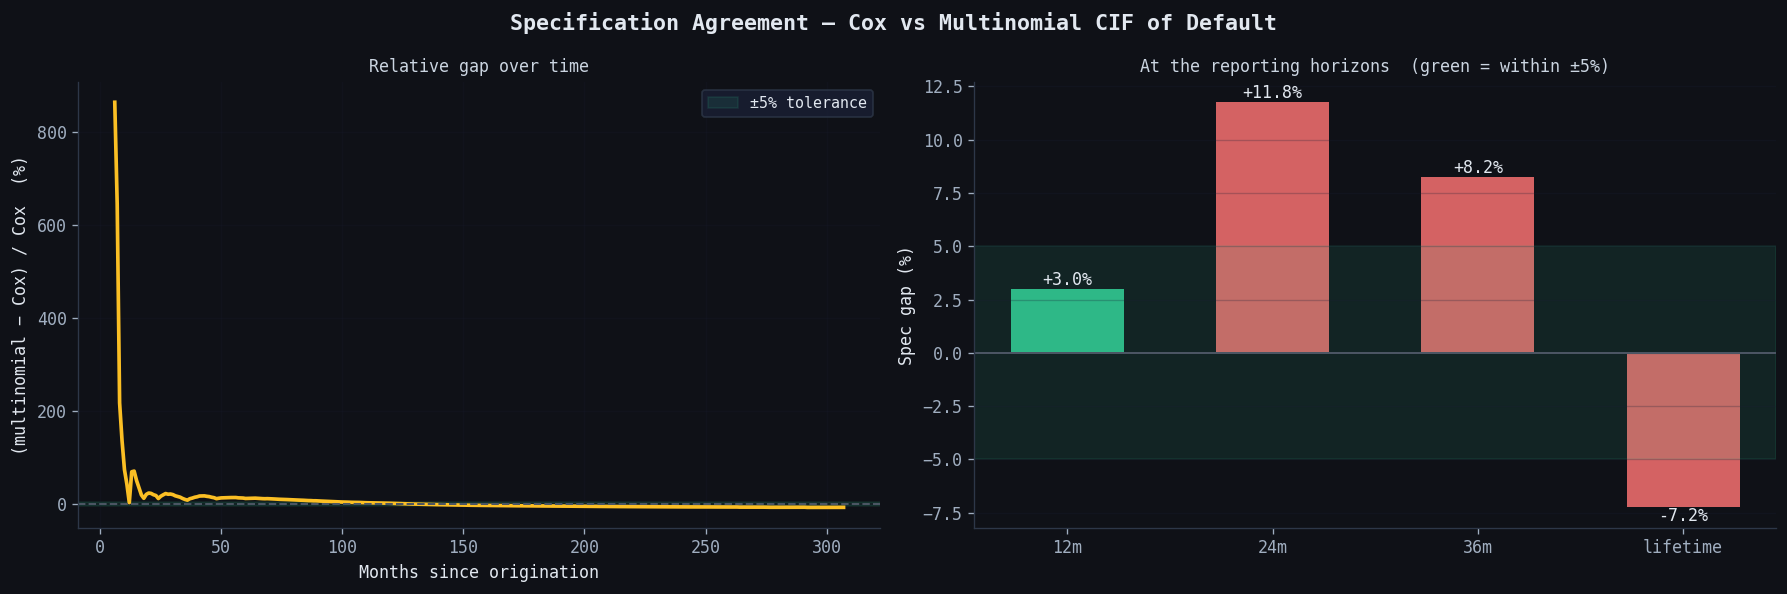

36-month spec gap: +8.2%  → DISAGREE — investigate before quoting either figure


In [24]:
if curves is not None and comparison is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("Specification Agreement — Cox vs Multinomial CIF of Default",
                 fontsize=13, color="#E2E8F0", fontweight="bold")

    ax = axes[0]
    valid = curves["cif_default_cox"] > 1e-6
    gap = ((curves["cif_default_multinomial"] - curves["cif_default_cox"])
           / curves["cif_default_cox"]).where(valid) * 100
    ax.plot(curves["month"], gap, color=COL["mnl"], linewidth=2.2)
    ax.axhspan(-5, 5, color=SUCCESS, alpha=0.10, label="±5% tolerance")
    ax.axhline(0, color="#4B5563", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Months since origination", fontsize=10)
    ax.set_ylabel("(multinomial − Cox) / Cox  (%)", fontsize=10)
    ax.set_title("Relative gap over time", color="#CBD5E1", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

    ax = axes[1]
    x = np.arange(len(comparison))
    colors = [SUCCESS if abs(g) <= 5 else DANGER for g in comparison["spec_gap_pct"]]
    bars = ax.bar(x, comparison["spec_gap_pct"], color=colors, alpha=0.85, width=0.55)
    for b, g in zip(bars, comparison["spec_gap_pct"]):
        ax.text(b.get_x() + b.get_width() / 2, g, f"{g:+.1f}%", ha="center",
                va="bottom" if g >= 0 else "top", fontsize=10, color="#E2E8F0")
    ax.axhspan(-5, 5, color=SUCCESS, alpha=0.10)
    ax.axhline(0, color="#4B5563", linewidth=1.2)
    ax.set_xticks(x); ax.set_xticklabels(comparison["horizon"], fontsize=10)
    ax.set_ylabel("Spec gap (%)", fontsize=10)
    ax.set_title("At the reporting horizons  (green = within ±5%)", color="#CBD5E1", fontsize=10)
    ax.grid(True, axis="y", alpha=0.25)
    for a in axes:
        a.spines["top"].set_visible(False); a.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()

    row36 = comparison[comparison["horizon"] == "36m"]
    if not row36.empty:
        g36 = float(row36["spec_gap_pct"].iloc[0])
        print(f"36-month spec gap: {g36:+.1f}%  → "
              f"{'the specifications agree' if abs(g36) <= 5 else 'DISAGREE — investigate before quoting either figure'}")

## 8. Expected Life for IFRS 9

Summing each loan's overall survival curve gives its **expected life**: `E[T] = Σ S(k)`, how long the loan is actually expected to stay on the balance sheet. It uses survival from *both* exits.

IFRS 9 lifetime ECL should run over the expected life, not the contractual term. For a 30-year mortgage the two differ by decades, because most loans refinance long before maturity. `07_macro_scenario_analysis.py` reads `competing_risks_expected_life.csv` when `config.IFRS9_USE_EXPECTED_LIFE` is set, and falls back to the contractual term for loans not in the file.

> The time grid ends at the longest duration observed in training, so expected life is truncated there. For young, slow-prepaying loans it is a lower bound.

Expected life — 950,842 loans scored (config.IFRS9_USE_EXPECTED_LIFE = True)
          count  mean   std   min   10%   50%    90%    max
split                                                      
oos    230568.0  67.9  20.5  19.9  43.7  65.4   95.7  189.0
oot    182297.0  82.7  17.5  31.8  61.9  80.7  106.1  189.7
train  537977.0  68.0  20.5  18.6  43.7  65.4   95.8  200.1

Mean expected life 70.8m vs mean contractual term 308.5m  → ratio 0.23


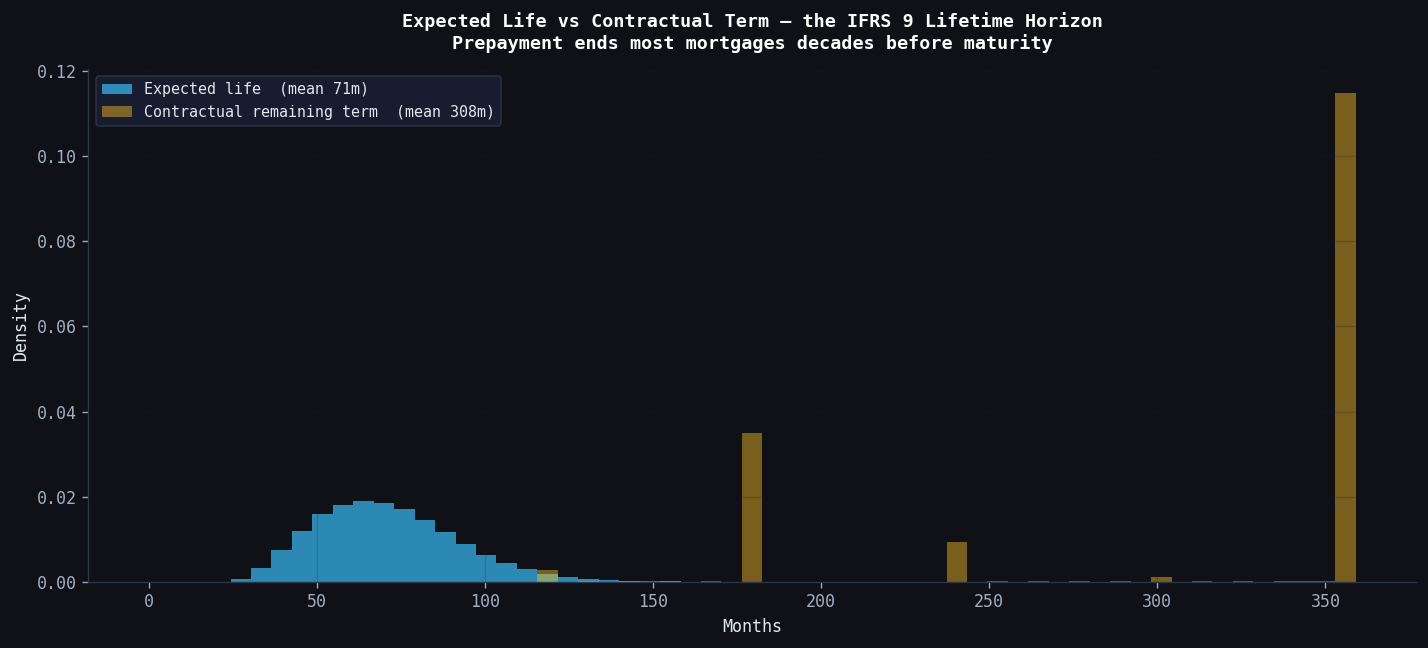

In [25]:
life_path = OUT_DIR / config.CR_EXPECTED_LIFE_FILE
if life_path.exists():
    life = pd.read_csv(life_path)
    print(f"Expected life — {len(life):,} loans scored "
          f"(config.IFRS9_USE_EXPECTED_LIFE = {config.IFRS9_USE_EXPECTED_LIFE})")
    print("=" * 70)
    print(life.groupby("split")["expected_life_months"]
          .describe(percentiles=[0.1, 0.5, 0.9]).round(1).to_string())

    contractual = None
    if panel is not None and "remaining_months" in panel.columns:
        # Contractual remaining term at each loan's first month on book.
        contractual = panel.loc[panel["period_month"] == 1, "remaining_months"].dropna()

    fig, ax = plt.subplots(figsize=(12, 5.5))
    hi = max(life["expected_life_months"].quantile(0.995),
             contractual.quantile(0.995) if contractual is not None and len(contractual) else 0)
    bins = np.linspace(0, hi, 60)
    ax.hist(life["expected_life_months"], bins=bins, density=True, alpha=0.7, color=ACCENT,
            label=f"Expected life  (mean {life['expected_life_months'].mean():.0f}m)")
    if contractual is not None and len(contractual):
        ax.hist(contractual, bins=bins, density=True, alpha=0.45, color=WARN,
                label=f"Contractual remaining term  (mean {contractual.mean():.0f}m)")
        print(f"\nMean expected life {life['expected_life_months'].mean():.1f}m vs "
              f"mean contractual term {contractual.mean():.1f}m  "
              f"→ ratio {life['expected_life_months'].mean() / contractual.mean():.2f}")
    ax.set_xlabel("Months", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_title("Expected Life vs Contractual Term — the IFRS 9 Lifetime Horizon\n"
                 "Prepayment ends most mortgages decades before maturity",
                 fontsize=11, fontweight="bold", color="white", pad=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()
else:
    print(f"{config.CR_EXPECTED_LIFE_FILE} not found. Run src/12_competing_risks.py first.")

del panel
gc.collect();

## Summary

| Quantity | What it answers | Used for |
|---|---|---|
| `1 − S_default(t)` (naive) | PD if prepayment were abolished | Nothing. It is the baseline being corrected. |
| `CIF_default(t)` (Cox, spec a) | PD before any other exit (**crude PD**) | The primary estimate |
| `CIF_default(t)` (multinomial, spec b) | Same quantity, independent method | Challenger and specification check |
| Aalen–Johansen (this notebook) | Same quantity, no model | Portfolio-level sanity check |
| Expected life `Σ S(k)` | How long the loan actually stays on book | IFRS 9 lifetime ECL horizon (Ch.6) |

**Key takeaways:**
- **Treating prepayment as censoring overstates PD.** The error is small at 12 months and grows with horizon, which is where it matters most: IFRS 9 Stage 2 lifetime ECL.
- **`CIF ≤ 1 − S` is an identity,** not a result. A run where it fails (§3) is a bug in the combination step, and the tests assert it.
- **Covariates act through both hazards.** A refinancing incentive that speeds prepayment lowers the default CIF even with no effect on the default hazard itself (§5).
- **The two specifications are independent,** so their agreement (§7) and their agreement with the model-free curve (§2) are the evidence that the CIF level is right.
- **Expected life, not contractual term,** should set the IFRS 9 lifetime horizon (§8).

Known scope limits of this script: covariates are held at origination values (no macro path), and the Cox models are the loan-level specification, not the discrete-time hazard of Notebook 5.

**Previous:** `05_Survival_Analysis.ipynb` (discrete-time default hazard) · `06_Macro_Scenario_Analysis.ipynb` (consumes expected life)